<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>n_bolus_duplicates</th>
      <th>n_basal_duplicates</th>
      <th>n_cgm_duplicates</th>
      <th>n_basal_repetitive</th>
      <th>n_basal_events</th>
      <th>n_bolus_events</th>
      <th>n_cgm_events</th>
      <th>n_patients</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>IOBP2</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>2304446</td>
      <td>8640808</td>
      <td>1730983</td>
      <td>7891499</td>
      <td>343</td>
    </tr>
    <tr>
      <th>Flair</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>44945</td>
      <td>142653</td>
      <td>3388050</td>
      <td>5506402</td>
      <td>115</td>
    </tr>
    <tr>
      <th>PEDAP</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>2654543</td>
      <td>263076</td>
      <td>6622228</td>
      <td>99</td>
    </tr>
    <tr>
      <th>DCLP3</th>
      <td>39</td>
      <td>2</td>
      <td>49</td>
      <td>2603</td>
      <td>2594186</td>
      <td>207682</td>
      <td>5673877</td>
      <td>112</td>
    </tr>
    <tr>
      <th>DCLP5</th>
      <td>33</td>
      <td>0</td>
      <td>5</td>
      <td>90318</td>
      <td>2529818</td>
      <td>226685</td>
      <td>5535106</td>
      <td>100</td>
    </tr>
    <tr>
      <th>ReplaceBG</th>
      <td>0</td>
      <td>0</td>
      <td>436</td>
      <td>64986</td>
      <td>448395</td>
      <td>414508</td>
      <td>13722600</td>
      <td>208</td>
    </tr>
    <tr>
      <th>Loop</th>
      <td>54</td>
      <td>0</td>
      <td>2227265</td>
      <td>10502324</td>
      <td>48080493</td>
      <td>2424001</td>
      <td>91431098</td>
      <td>845</td>
    </tr>
    <tr>
      <th>T1DEXI</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>244751</td>
      <td>1052843</td>
      <td>85440</td>
      <td>3756150</td>
      <td>489</td>
    </tr>
    <tr>
      <th>T1DEXIP</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>29236</td>
      <td>219453</td>
      <td>19122</td>
      <td>679913</td>
      <td>239</td>
    </tr>
  </tbody>
</table>
</div>

We know that we have a lot of repetitive basal rates that should be removed to reduce computational burden.
For PEDAP we already did this, however, this might create long gaps when basal rates are constant for a long time (flat basal).
Then, it is unclear if basal data was missing or we removed it. So dropping repetitive values should not create too large gaps.

In [29]:
import pandas as pd
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import pandas as pd
import line_profiler as lp

%matplotlib widget


In [30]:
def integrate_zoh(df):
    x = (df.datetime.diff().dt.total_seconds()/3600)[1:]
    y = df['basal_rate'][:-1]
    if len(x) == 0:
        r= np.nan
    else:
        r = np.sum(x.values * y.values)
    return r

def draw_basal(df,ax):
    df = df.sort_values('datetime')
    ax.step(df['datetime'], df['basal_rate'], where='post', color='blue', alpha=0.5)
    ax.scatter(df['datetime'], df['basal_rate'], s=5, color='blue')
    return ax


## Generate artificial dataset

,datetime,basal_rate
0,2023-01-01 13:00:00,1.0
1,2023-01-03 19:00:00,0.5
2,2023-01-01 08:00:00,0.5
3,2023-01-03 07:00:00,1.0


-106.5

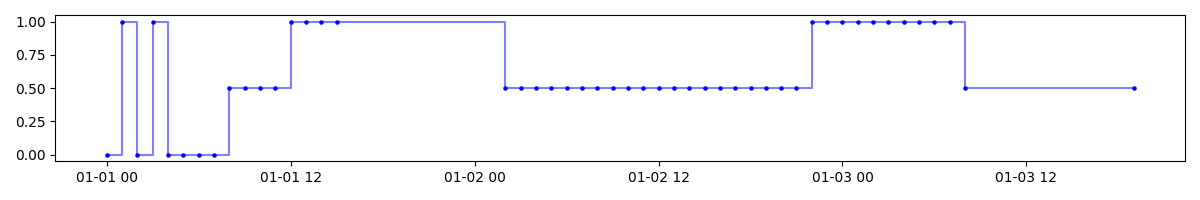

In [31]:
# Generate a date range with 1-hour intervals
start_date = '2023-01-01'
values = (
    [0,1,0,1] * 1 + 
    [0] * 4 + 
    [0.5] * 4 + 
    [1] * 4 + 
    [np.nan] * 10 + 
    [0.5] * 20 + 
    [1]*10+
    [0.5]*1+
    [np.nan] * 10 +
    [0.5]*1
)
date_range = pd.date_range(start=start_date, periods=len(values), freq='1h')

df = pd.DataFrame({
    'datetime': date_range,
    'basal_rate': values
}).dropna()
df = df.sample(frac=1).reset_index(drop=True)
display(df.head(4))

f = plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
plt.tight_layout()

integral = integrate_zoh(df)
display(integral)


In [32]:
np.concatenate([np.arange(0, 10), [19]])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 19])

## dropping repetitive values

In [33]:
#first, find repetitive values
def get_repetitive_groups(df,datetime_col,value_col):
#    assert df[datetime_col].is_monotonic_increasing
    df = df.sort_values(datetime_col)
    grp = (df[value_col].diff() != 0).cumsum()
    return grp

,original,filtered,difference
0,-106.5,38.0,144.5


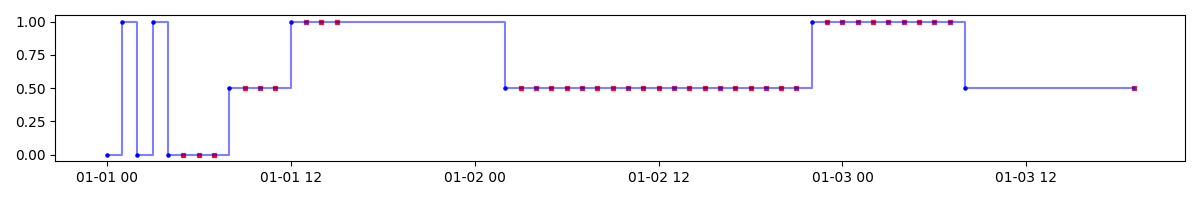

In [34]:
#get the repetitive rows
df = df.sort_values('datetime') 
df['grp'] = get_repetitive_groups(df,'datetime','basal_rate')
df_filtered = df.groupby('grp').head(1) #head(1) returns the first row, therefore must be sorted
df_repetitive = df.drop(df_filtered.index)

#draw and mark the repetitive values in red
f = plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
plt.scatter(df_repetitive['datetime'], df_repetitive['basal_rate'], s=10, color='red',marker='x')
plt.tight_layout()

integral_filtered = integrate_zoh(df_filtered)
# Merge the integrals into a DataFrame and calculate the difference
integrals = pd.DataFrame({'original': [integral], 'filtered': [integral_filtered]})
integrals['difference'] = integrals['filtered'] - integrals['original']

# Display the integrals and the difference
display(integrals)

## Keep last values
Since we remvoe the last value, the integral is not calculated correctly, so we need to always keep the last value.

,original,filtered,difference
0,-106.5,43.5,150.0


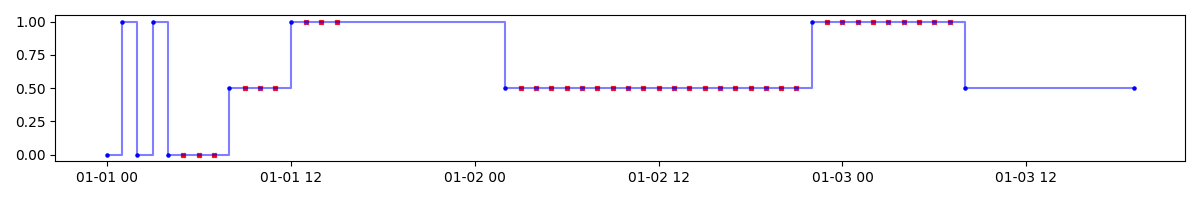

In [35]:
df.loc[df.tail(1).index,'grp']+=1

i_grp_starts = df.groupby(['grp']).head(1).index
df_filtered = df.loc[i_grp_starts]
df_repetitive = df.drop(i_grp_starts)

#draw and mark the repetitive values in red
f = plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
plt.scatter(df_repetitive['datetime'], df_repetitive['basal_rate'], s=10, color='red',marker='x')
plt.tight_layout()

integral_filtered = integrate_zoh(df_filtered)
# Merge the integrals into a DataFrame and calculate the difference
integrals = pd.DataFrame({'original': [integral], 'filtered': [integral_filtered]})
integrals['difference'] = integrals['filtered'] - integrals['original']

# Display the integrals and the difference
display(integrals)


## Maintain support points
The problem is now, that we remove all repetitions, in the middle this could be incorrectly intterpreted as missing data. Therefore we want to add support points at least every x hours.

,original,filtered,difference
0,-106.5,43.5,150.0


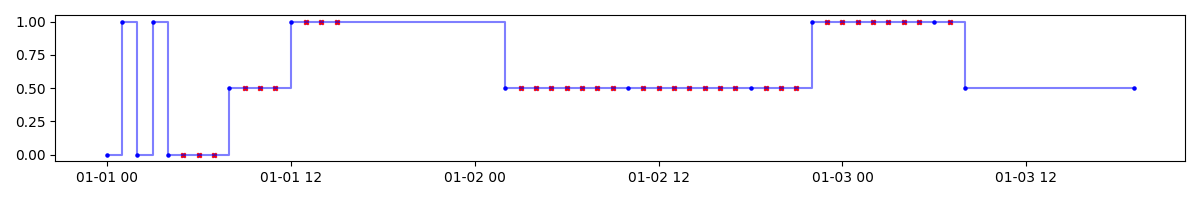

In [36]:
max_duration = pd.Timedelta(hours=8)
df['sub_grped'] = df.groupby(['grp']).datetime.transform(lambda x: (x.diff()).cumsum()//max_duration).fillna(0)
df['sub_grped'] = df['grp']*10000 + df['sub_grped']

df_filtered = df.groupby(['sub_grped']).head(1)
df_repetitive = df.drop(df_filtered.index)

#draw and mark the repetitive values in red
f = plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
plt.scatter(df_repetitive['datetime'], df_repetitive['basal_rate'], s=10, color='red',marker='x')
plt.tight_layout()

integral_filtered = integrate_zoh(df_filtered)
# Merge the integrals into a DataFrame and calculate the difference
integrals = pd.DataFrame({'original': [integral], 'filtered': [integral_filtered]})
integrals['difference'] = integrals['filtered'] - integrals['original']

# Display the integrals and the difference
display(integrals)



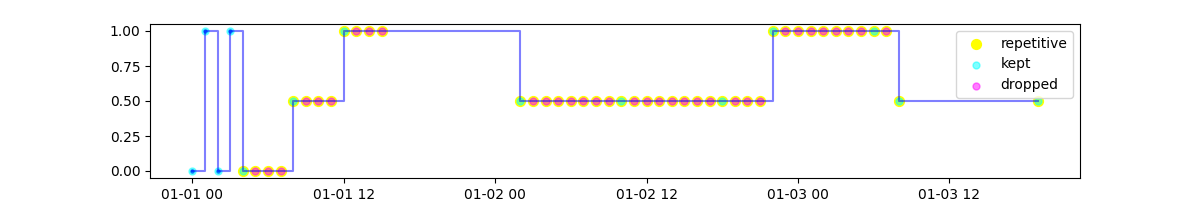

In [37]:
def get_repetitive_indexes(df, datetime_col, value_col, max_duration):
    df = df.sort_values(datetime_col) 
    grp = get_repetitive_groups(df,datetime_col,value_col)
    i_all_repetitives = grp[grp.map(grp.value_counts()) > 1].index
    
    #keep last value
    grp.iloc[-1] += 1 
    
    #subsplit groups
    sub_grp = grp*10000 + df.groupby(grp).datetime.transform(lambda x: (x.diff()).cumsum()//max_duration).fillna(0)
    
    #keep only the first of each subgroup
    i_keep = sub_grp[sub_grp.duplicated(keep='first') == False].index
    i_drop = np.setdiff1d(i_all_repetitives, i_keep)
    return i_all_repetitives, i_keep, i_drop

i_all_repetitives, i_keep, i_drop = get_repetitive_indexes(df, 'datetime', 'basal_rate', max_duration=max_duration)
    

plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
temp = df.loc[i_all_repetitives]

plt.scatter(temp['datetime'], temp['basal_rate'], s=50, color='yellow',marker='o',alpha=1,label='repetitive')
temp = df.loc[i_keep]
plt.scatter(temp['datetime'], temp['basal_rate'], s=25, color='cyan',marker='o',alpha=.5,label='kept')
temp = df.loc[i_drop]
plt.scatter(temp['datetime'], temp['basal_rate'], s=25, color='magenta',marker='o',alpha=.5,label='dropped')
plt.legend()


## Benchmark speed

In [38]:
import line_profiler

#dataset
n_samples = 100000
basal_rate = np.random.choice([0,1,1,1,1,1], size=n_samples)
datetime = pd.date_range(start='2023-01-01', periods=n_samples, freq='1h')
df_large = pd.DataFrame({'datetime': datetime, 'basal_rate': basal_rate})

# Line profiler
lp = line_profiler.LineProfiler()
lp.add_function(get_repetitive_indexes)
get_repetitive_indexes_wrapper = lp.wrap_function(get_repetitive_indexes)
i_all_repetitives, i_keep, i_drop = get_repetitive_indexes_wrapper(df_large, 'datetime', 'basal_rate', max_duration=max_duration)

lp.print_stats()
stats = lp.get_stats()
for key in stats.timings.keys():
    print(key[0])
    print(f'Execution time {sum([t[2] for t in stats.timings[key]])/1000000000:.6f} seconds')


Timer unit: 1e-09 s

Total time: 5.95802 s
File: /var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_52957/2980003033.py
Function: get_repetitive_indexes at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def get_repetitive_indexes(df, datetime_col, value_col, max_duration):
     2         1    1623000.0    2e+06      0.0      df = df.sort_values(datetime_col) 
     3         1    2346000.0    2e+06      0.0      grp = get_repetitive_groups(df,datetime_col,value_col)
     4         1    3821000.0    4e+06      0.1      i_all_repetitives = grp[grp.map(grp.value_counts()) > 1].index
     5                                               
     6                                               #keep last value
     7         1     784000.0 784000.0      0.0      grp.iloc[-1] += 1 
     8                                               
     9                                               #subsplit groups
    10       

## implement a improved version

In [39]:
def get_repetitive_indexes_improved(df, datetime_col, value_col, max_duration):
    assert df[datetime_col].is_monotonic_increasing
    grp = get_repetitive_groups(df,datetime_col,value_col)
    i_all_repetitives = grp[grp.map(grp.value_counts()) > 1].index
    
    #keep last value
    grp.iloc[-1] += 1 
    
    #subsplit groups
    #df['grp'] = grp
    dur = (df.datetime-df.datetime.iloc[0])
    dur = dur - dur.groupby(grp).transform('first')#within group duration
    sub_grp = dur//max_duration

    assert np.all(sub_grp<=1000)
    final_grp = 1000*grp + sub_grp
    
    #df['grp'] = grp
    #df['dur'] = dur
    #df['sub_grp'] = sub_grp
    
    #keep only the first of each subgroup
    i_keep = final_grp.groupby(final_grp).head(1).index

    i_drop = np.setdiff1d(i_all_repetitives, i_keep)
    return i_all_repetitives, i_keep, i_drop

### check if it does the right thing

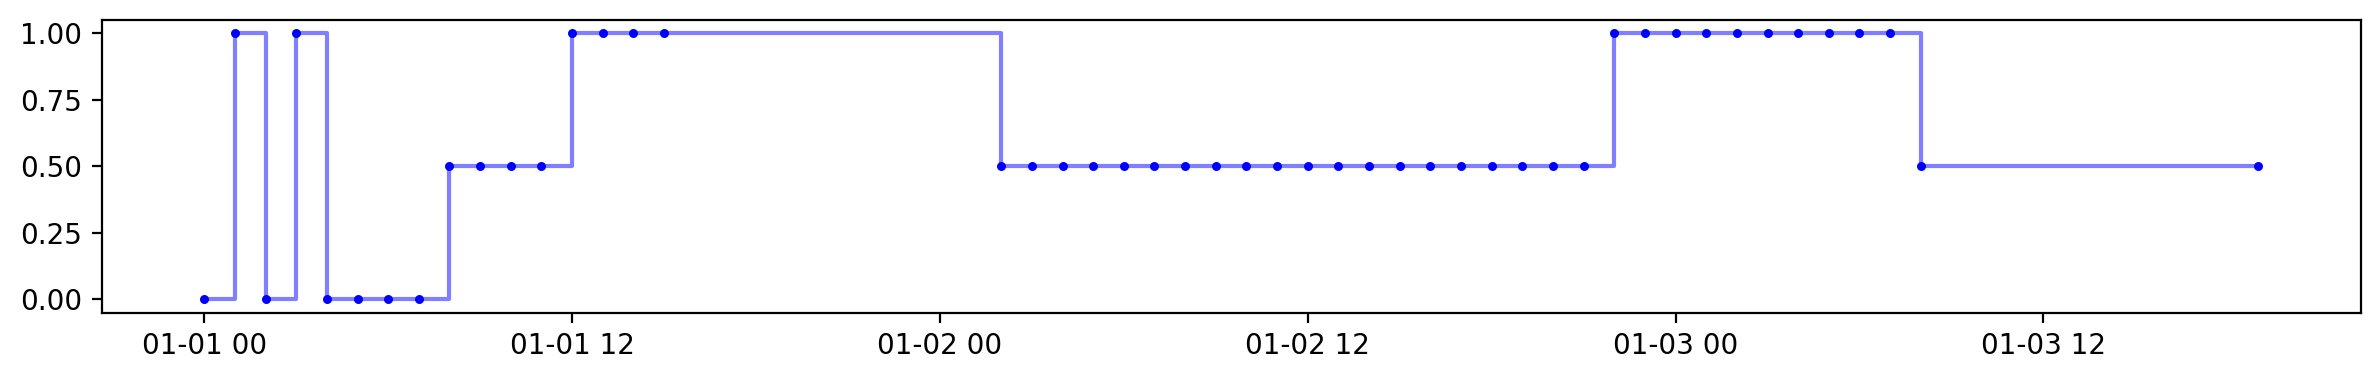

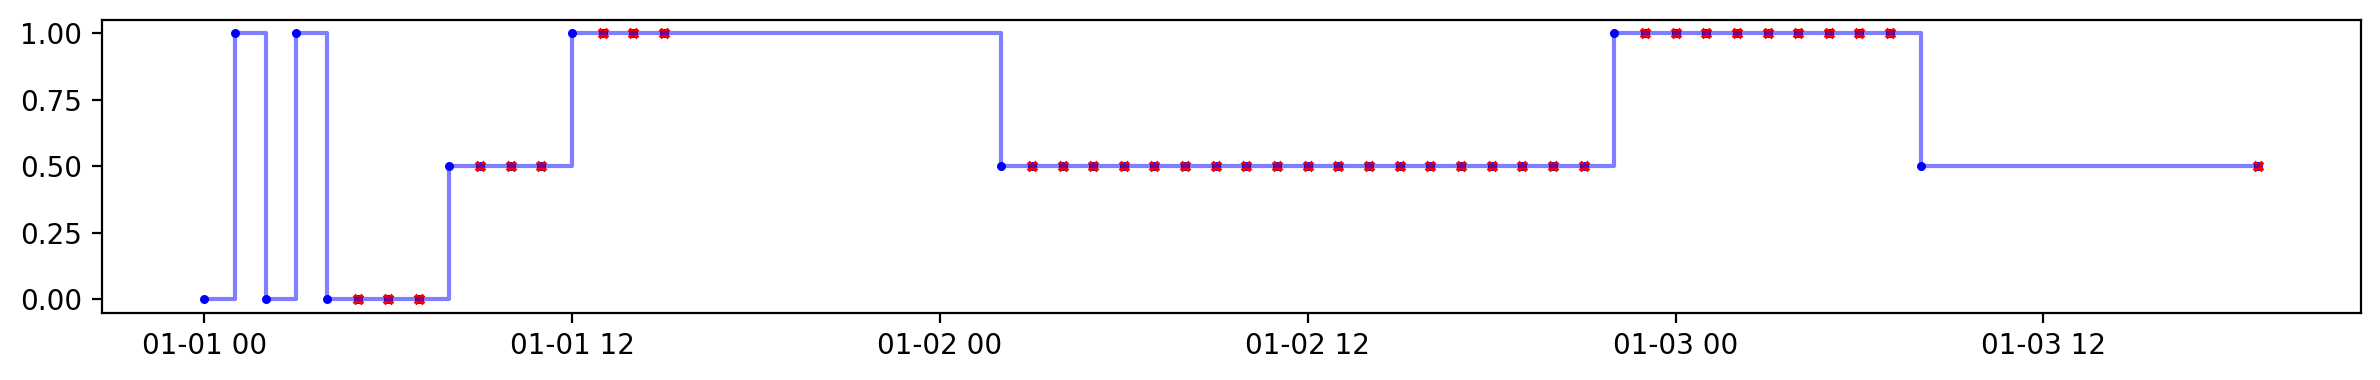

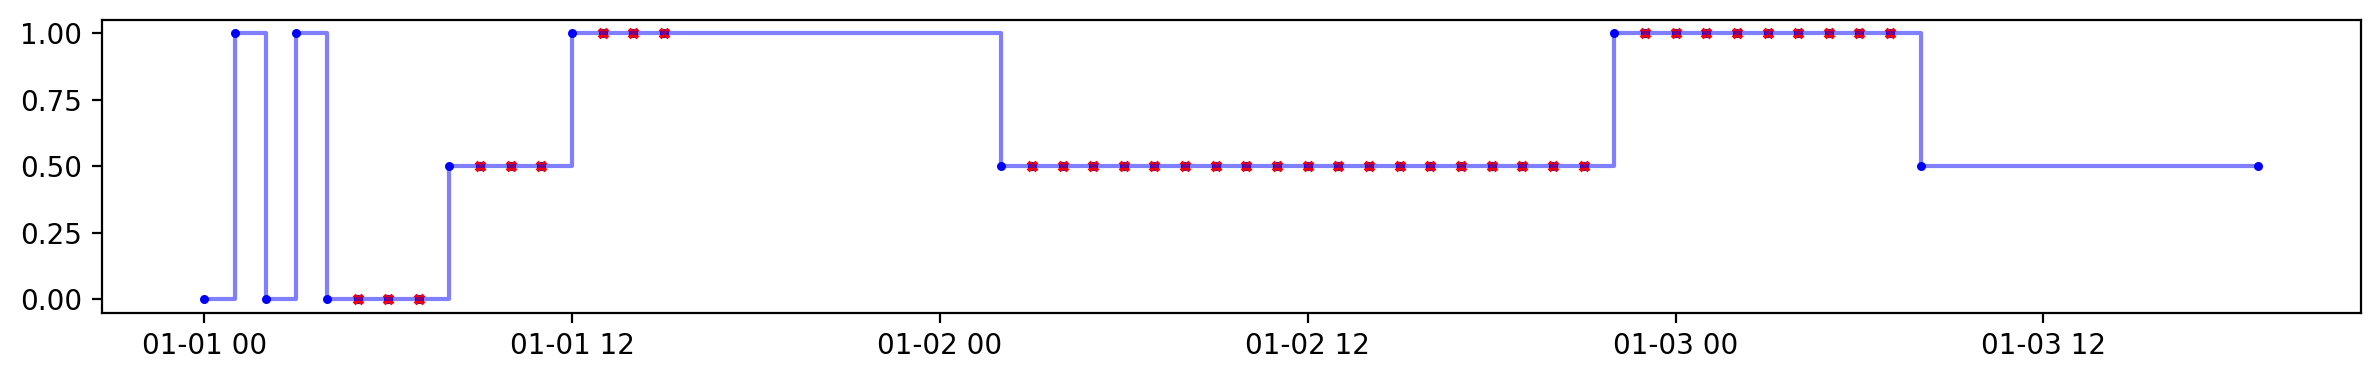

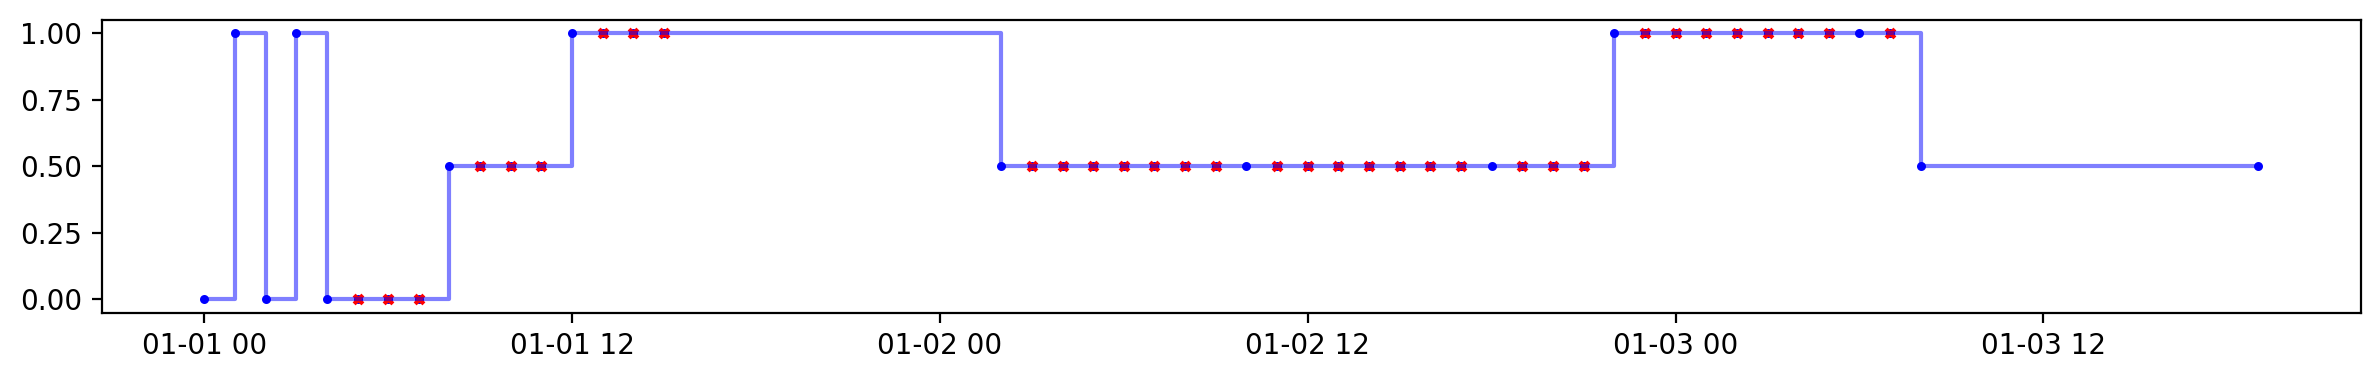

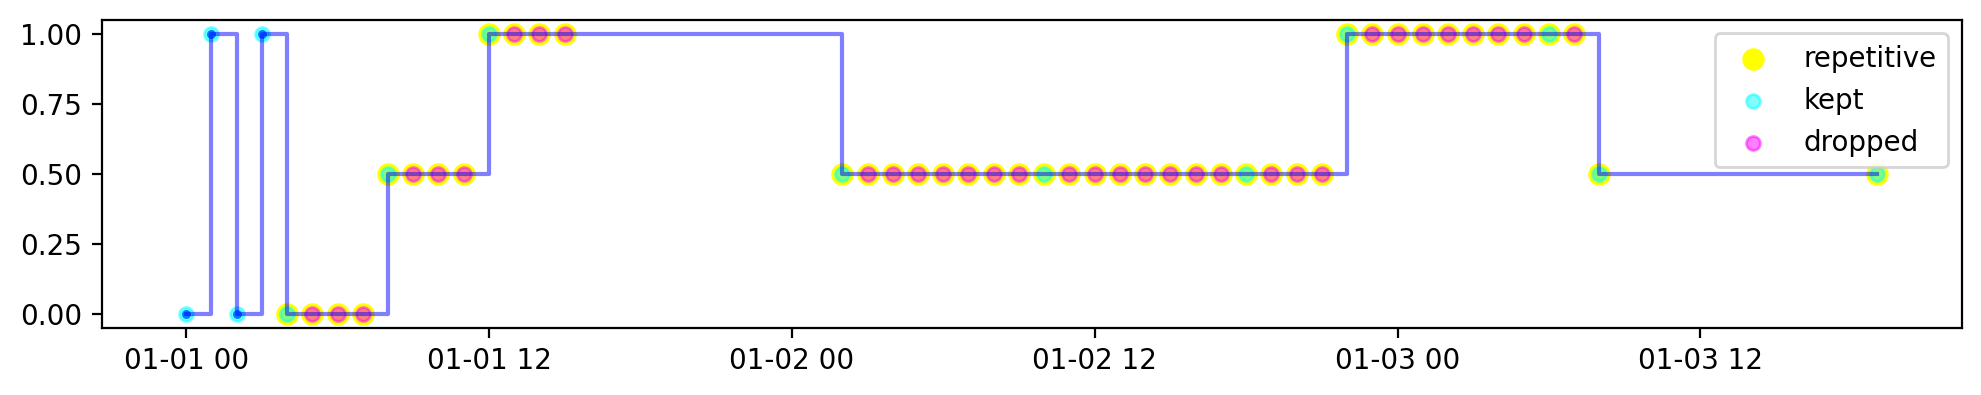

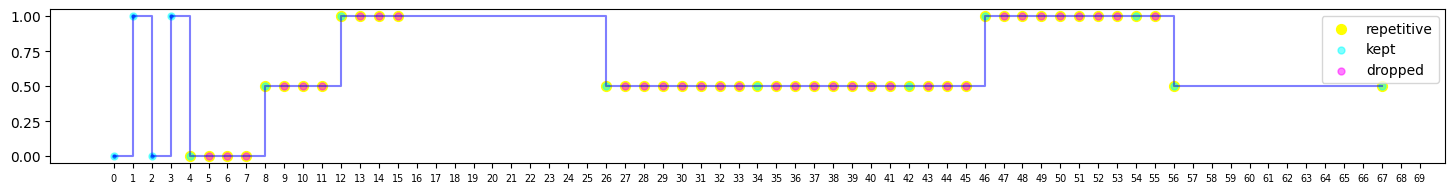

The integraals are 43.5 and 43.5, difference 0.0
Original df has 48 rows, filtered df has 14 rows


In [40]:
i_all_repetitives, i_keep, i_drop = get_repetitive_indexes_improved(df, 'datetime', 'basal_rate', max_duration=max_duration)
%matplotlib inline
plt.figure(figsize=(18, 2)); ax=plt.gca()
draw_basal(df,ax)
temp = df.loc[i_all_repetitives]
ax.scatter(temp['datetime'], temp['basal_rate'], s=50, color='yellow',marker='o',alpha=1,label='repetitive')
temp = df.loc[i_keep]
ax.scatter(temp['datetime'], temp['basal_rate'], s=25, color='cyan',marker='o',alpha=.5,label='kept')
temp = df.loc[i_drop]
ax.scatter(temp['datetime'], temp['basal_rate'], s=25, color='magenta',marker='o',alpha=.5,label='dropped')

date_range = pd.date_range(df.datetime.min(),periods=70,freq='1h')
ax.set_xticks(date_range)
ax.set_xticklabels(np.arange(0, len(date_range)),fontsize='x-small')

plt.legend()
plt.show()


#compare the sum 
td_original = integrate_zoh(df)
td_improved = integrate_zoh(df.drop(i_drop))
print(f"The integraals are {td_original} and {td_improved}, difference {td_original-td_improved}")
#report number of rows 
print(f"Original df has {len(df)} rows, filtered df has {len(df.drop(i_drop))} rows")

 


In [41]:
i_keep

Index([14, 22, 27, 16, 38, 2, 21, 4, 30, 28, 9, 19, 40, 1], dtype='int64')

### benchmark time

Timer unit: 1e-09 s

Total time: 0.016712 s
File: /var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_52957/4284980097.py
Function: get_repetitive_indexes_improved at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def get_repetitive_indexes_improved(df, datetime_col, value_col, max_duration):
     2         1     359000.0 359000.0      2.1      assert df[datetime_col].is_monotonic_increasing
     3         1    2718000.0    3e+06     16.3      grp = get_repetitive_groups(df,datetime_col,value_col)
     4         1    3721000.0    4e+06     22.3      i_all_repetitives = grp[grp.map(grp.value_counts()) > 1].index
     5                                               
     6                                               #keep last value
     7         1     113000.0 113000.0      0.7      grp.iloc[-1] += 1 
     8                                               
     9                                             

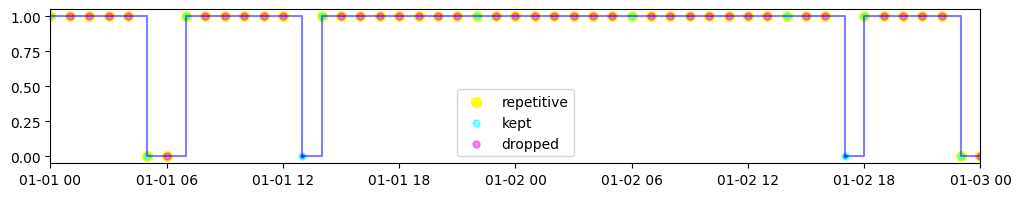

In [42]:
%matplotlib inline
import line_profiler
lp = line_profiler.LineProfiler()
lp.add_function(get_repetitive_indexes_improved)
get_repetitive_indexes_wrapper = lp.wrap_function(get_repetitive_indexes_improved)

i_all_repetitives, i_keep, i_drop = get_repetitive_indexes_wrapper(df_large, 'datetime', 'basal_rate', max_duration=max_duration)
lp.print_stats()
stats = lp.get_stats()
for key in stats.timings.keys():
    print(key[0])
    print(f'Execution time {sum([t[2] for t in stats.timings[key]])/1000000000:.6f} seconds')


#compare the sum 
td_original = integrate_zoh(df_large)
td_improved = integrate_zoh(df_large.drop(i_drop))
print(f"The integraals are {td_original} and {td_improved}, difference {td_original-td_improved}")
print(f"Original df has {len(df_large)} rows, filtered df has {len(df_large.drop(i_drop))} rows")


plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df_large,ax)
temp = df_large.loc[i_all_repetitives]
ax.scatter(temp['datetime'], temp['basal_rate'], s=50, color='yellow',marker='o',alpha=1,label='repetitive')
temp = df_large.loc[i_keep]
ax.scatter(temp['datetime'], temp['basal_rate'], s=25, color='cyan',marker='o',alpha=.5,label='kept')
temp = df_large.loc[i_drop]
ax.scatter(temp['datetime'], temp['basal_rate'], s=25, color='magenta',marker='o',alpha=.5,label='dropped')
plt.legend()
plt.xlim(df_large.datetime.min(),df_large.datetime.min()+pd.Timedelta(hours=48))
plt.show()

## Testing it on a real study

In [43]:
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '..'))
from studies.dataset_initializer import initialize_datasets
studies = initialize_datasets(os.path.join(os.getcwd(), '..', 'data', 'raw'))

[18:54:02] Unmatched folders:
[18:54:02]   .DS_Store
[18:54:02]   skip
[18:54:02]   .gitkeep
[18:54:02] Successfully matched studies with folders:
[18:54:02]   IOBP2 : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/IOBP2 RCT Public Dataset.zip
[18:54:02]   Flair : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/FLAIRPublicDataSet.zip
[18:54:02]   PEDAP : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/PEDAP Public Dataset - Release 4 - 2025-04-10.zip
[18:54:02]   DCLP3 : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/DCLP3 Public Dataset - Release 3 - 2022-08-04.zip
[18:54:02]   DCLP5 : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/DCLP5_Dataset_2022-01-20-5e0f3b16-c890-4ace-9e3b-531f3687cf53.zip
[18:54:02]   ReplaceBG : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/REPLACE-BG Dataset-79f6bdc8-3c51-4736-a39f-c4c0f71d45e5
[18:54:02]   T1DEXI : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/T1DEXI - DATA FOR UPLOAD.zip
[18:54

In [44]:
study = studies['Flair']
df_basal = study.extract_basal_event_history()
df_basal = df_basal.sort_values('datetime')

In [45]:
def drop_repetitives(df):# -> Any:
    _, _, i_drop = get_repetitive_indexes_improved(df, 'datetime', 'basal_rate', max_duration=max_duration)
    df = df.drop(i_drop)
    return df
df_basal_filt = df_basal.groupby(['patient_id']).apply(drop_repetitives).reset_index(drop=True)

/var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_52957/494946520.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_basal_filt = df_basal.groupby(['patient_id']).apply(drop_repetitives).reset_index(drop=True)


In [46]:
#sample counts
print(f"Original {len(df_basal)} rows, filtered {len(df_basal_filt)} rows: {(len(df_basal)-len(df_basal_filt))} ({(len(df_basal)-len(df_basal_filt))/len(df_basal)*100:.2f}%) rows dropped)")
#compare the sum
td_original = df_basal.groupby(['patient_id']).apply(integrate_zoh,include_groups=False).sum()
td_improved = df_basal_filt.groupby(['patient_id']).apply(integrate_zoh,include_groups=False).sum()
print(f"The integraals are {td_original:.2f}U and {td_improved:.2f}U, difference {td_original-td_improved:.4f}U")

Original 142653 rows, filtered 102967 rows: 39686 (27.82%) rows dropped)
The integraals are 231134.29U and 231134.29U, difference -0.0000U
